<a href="https://colab.research.google.com/github/oguzhanguler1/insurance_regression/blob/main/medical_insurance_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [282]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [283]:
df = pd.read_csv('insurance.csv')

In [284]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [285]:
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [286]:
df.groupby("smoker")["charges"].mean()



,charges
smoker,
no,8434.268298
yes,32050.231832


In [287]:
df.groupby("region")["charges"].mean()

,charges
region,
northeast,13406.384516
northwest,12417.575374
southeast,14735.411438
southwest,12346.937377


In [288]:
df.corr(numeric_only=True)["charges"].drop("charges").sort_values(ascending=False)

,charges
age,0.299008
bmi,0.198341
children,0.067998


In [289]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [290]:
X["smoker"] = X["smoker"].map({
    "no": 0,
    "yes": 1
})

In [291]:
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), ["sex", "region"])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [292]:
numeric_columns = ["age", "bmi", "children", "charges"]

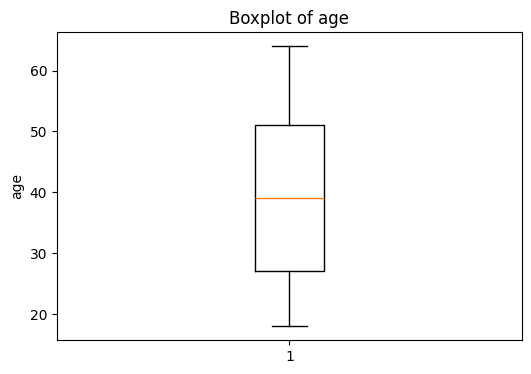

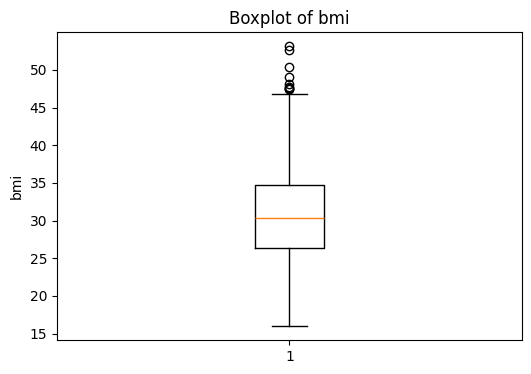

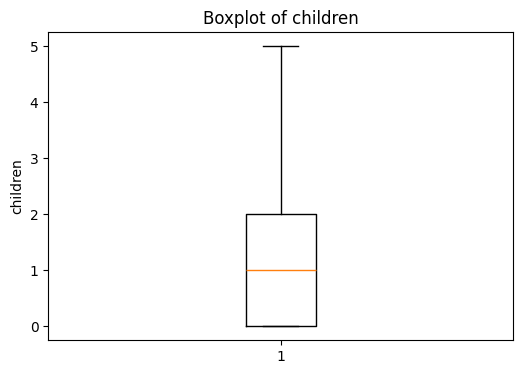

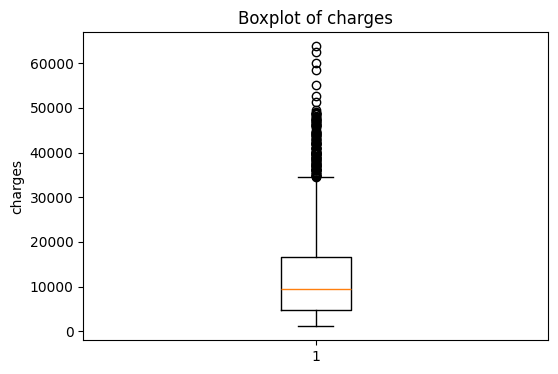

In [293]:
import matplotlib.pyplot as plt

for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

In [294]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 1)

In [295]:
print(X[:5])
print(X.dtype)

[[ 1.    0.    0.    0.    0.    1.   19.   27.9   0.    1.  ]
 [ 0.    1.    0.    0.    1.    0.   18.   33.77  1.    0.  ]
 [ 0.    1.    0.    0.    1.    0.   28.   33.    3.    0.  ]
 [ 0.    1.    0.    1.    0.    0.   33.   22.7   0.    0.  ]
 [ 0.    1.    0.    1.    0.    0.   32.   28.88  0.    0.  ]]
float64


In [296]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 200, random_state = 0)
regressor.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=0)

In [297]:
y_pred = regressor.predict(X_test)

In [298]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2732.0010626526496
MSE: 24010789.679207016
RMSE: 4900.080578848374
R2 Score: 0.8480558100900526


In [299]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
559,1646.42970,1768.150210
1087,11353.22760,11985.711026
1020,8798.59300,10407.264080
460,10381.47870,11170.006117
802,2103.08000,2106.719900
298,38746.35510,40757.056314
481,9304.70190,9608.880263
616,11658.11505,11805.036379
763,3070.80870,3092.466731
750,19539.24300,19730.849984


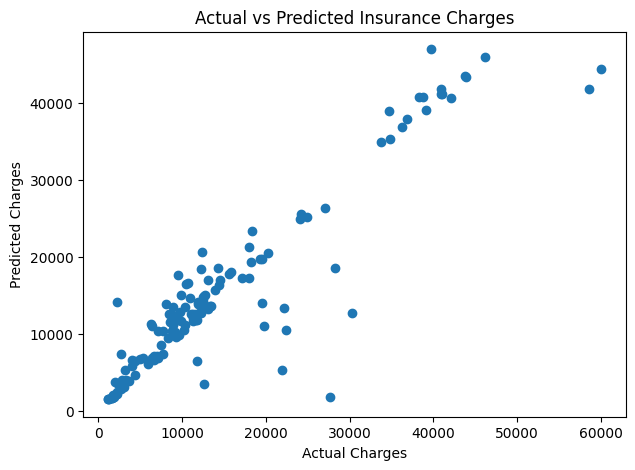

In [300]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()

In [301]:
new_person = pd.DataFrame([[27, "male", 23.8, 0, 1, "southwest"]],
                          columns=["age", "sex", "bmi", "children", "smoker", "region"])

print(regressor.predict(ct.transform(new_person))[0])

17972.8965153


In [302]:
from sklearn.linear_model import LinearRegression
regressor2 = LinearRegression()
regressor2.fit(X_train, y_train)

LinearRegression()

In [303]:
y_pred2 = regressor2.predict(X_test)
comparison = pd.DataFrame({
    "Predicted": y_pred2,
    "Actual": y_test.values
})

comparison.head(10)

,Predicted,Actual
0,4235.718838,1646.42970
1,12834.089997,11353.22760
2,12642.508782,8798.59300
3,13437.426110,10381.47870
4,493.599588,2103.08000
5,32201.358018,38746.35510
6,13004.343724,9304.70190
7,12197.633330,11658.11505
8,3555.373601,3070.80870
9,29331.851710,19539.24300


In [304]:
mae2 = mean_absolute_error(y_test, y_pred2)
mse2 = mean_squared_error(y_test, y_pred2)
rmse2 = np.sqrt(mse2)
r21 = r2_score(y_test, y_pred2)

print("MAE:", mae2)
print("MSE:", mse2)
print("RMSE:", rmse2)
print("R2 Score:", r21)

MAE: 4376.2631634711115
MSE: 43104275.10499073
RMSE: 6565.384612114566
R2 Score: 0.7272291228241007


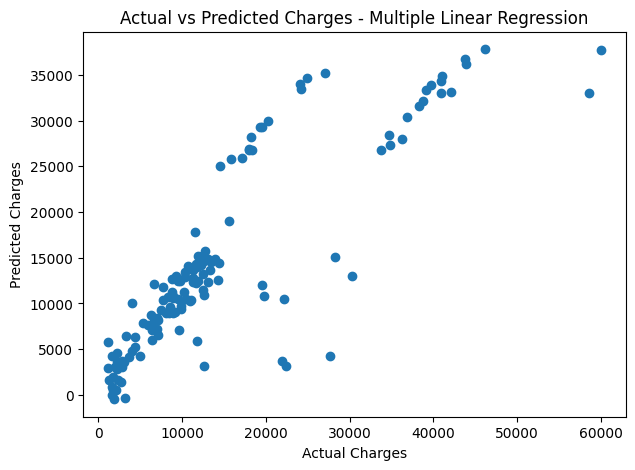

In [305]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred2)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges - Multiple Linear Regression")
plt.show()

In [306]:
y_SVR = y_train.values.reshape(len(y_train),1)

In [307]:
print(y_SVR)

[[24603.05]
 [ 1731.68]
 [ 1632.56]
 ...
 [44641.2 ]
 [19444.27]
 [11554.22]]


In [308]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X_SVR = sc_X.fit_transform(X_train)
y_SVR = sc_y.fit_transform(y_SVR)
X_test_SVR = sc_X.transform(X_test)

In [309]:
from sklearn.svm import SVR
regressor3 = SVR(kernel = 'rbf')
regressor3.fit(X_SVR, y_SVR)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

In [310]:
y_pred3_scaled = regressor3.predict(X_test_SVR)

In [311]:
y_pred3 = sc_y.inverse_transform(y_pred3_scaled.reshape(-1, 1))

In [312]:
mae3 = mean_absolute_error(y_test, y_pred3)
mse3 = mean_squared_error(y_test, y_pred3)
rmse3 = np.sqrt(mse3)
r22 = r2_score(y_test, y_pred3)

print("SVR MAE:", mae3)
print("SVR MSE:", mse3)
print("SVR RMSE:", rmse3)
print("SVR R2 Score:", r22)

SVR MAE: 2629.214571315274
SVR MSE: 24170113.172943875
SVR RMSE: 4916.310931271931
SVR R2 Score: 0.8470475850581857


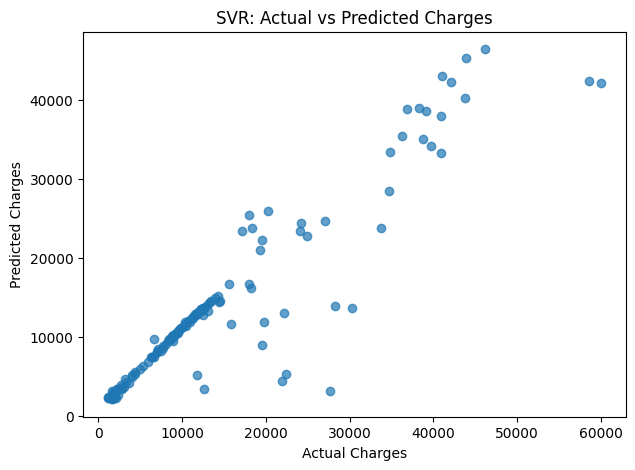

In [313]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred3, alpha=0.7)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("SVR: Actual vs Predicted Charges")
plt.show()